# Stack Overflow Developer Survey Analysis
## Udacity Data Science Nanodegree — Write a Data Science Blog Post
### CRISP-DM Framework

**Questions of Interest:**
1. What factors most influence a developer's annual salary?
2. How does education level relate to job satisfaction?
3. Can we predict whether a developer earns above the median salary?

---
*Dataset: Stack Overflow Developer Survey (simulated representative sample)*


---
## Step 1: Business Understanding (CRISP-DM Phase 1)

The Stack Overflow Annual Developer Survey is one of the largest surveys of software developers worldwide. Understanding what drives developer salaries and satisfaction helps:
- Job seekers benchmark their compensation
- Employers structure competitive offers
- Educators understand which skills/degrees pay off

We'll follow CRISP-DM: Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Deployment


---
## Step 2: Data Understanding — Exploratory Data Analysis (CRISP-DM Phase 2)


In [5]:
import micropip
await micropip.install("seaborn")

In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [7]:
# Load dataset
df = pd.read_csv('survey_results_public.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")


Dataset shape: (2000, 11)

Column names:
['Country', 'DevType', 'EdLevel', 'Employment', 'YearsCodePro', 'Age', 'ConvertedCompYearly', 'JobSat', 'RemoteWork', 'LanguageHaveWorkedWith', 'OpSys']


In [8]:
# First look at the data
df.head()


,Country,DevType,EdLevel,Employment,YearsCodePro,Age,ConvertedCompYearly,JobSat,RemoteWork,LanguageHaveWorkedWith,OpSys
0,India,Data scientist or machine learning specialist,Masters degree,Employed full-time,27,35-44 years old,5000.000000,4,In-person,PHP;Kotlin;Java;C++,macOS
1,Netherlands,Desktop developer,Some college,Employed full-time,25,35-44 years old,37496.277965,4,Remote,C#;Go;Rust,Windows
2,Canada,Front-end developer,Bachelors degree,Student,27,18-24 years old,67776.378205,3,Remote,JavaScript;PHP;Kotlin;C++,macOS
3,Germany,Desktop developer,Masters degree,Employed full-time,11,55-64 years old,NaN,2,In-person,C++,Windows
4,United States,Data scientist or machine learning specialist,Masters degree,Student,17,25-34 years old,NaN,5,Remote,JavaScript;Java;Kotlin;PHP,Windows


In [9]:
# Basic statistics
df.describe(include='all')


,Country,DevType,EdLevel,Employment,YearsCodePro,Age,ConvertedCompYearly,JobSat,RemoteWork,LanguageHaveWorkedWith,OpSys
count,2000,2000,2000,2000,2000,2000,1372.000000,2000.000000,2000,2000,2000
unique,10,8,6,6,32,6,NaN,NaN,3,932,4
top,United States,Full-stack developer,Bachelors degree,Employed full-time,1,25-34 years old,NaN,NaN,Hybrid,Rust,Windows
freq,705,269,937,1327,84,818,NaN,NaN,936,65,1015
mean,NaN,NaN,NaN,NaN,NaN,NaN,77132.779491,3.707000,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,40524.528194,1.106238,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,5000.000000,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,44660.878811,3.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,72788.133802,4.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,112139.649984,5.000000,NaN,NaN,NaN


In [10]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("Columns with missing values:")
print(missing_df)


Columns with missing values:
                     Missing Count  Missing %
ConvertedCompYearly            628       31.4


### 2.1 Salary Distribution (Target Variable)

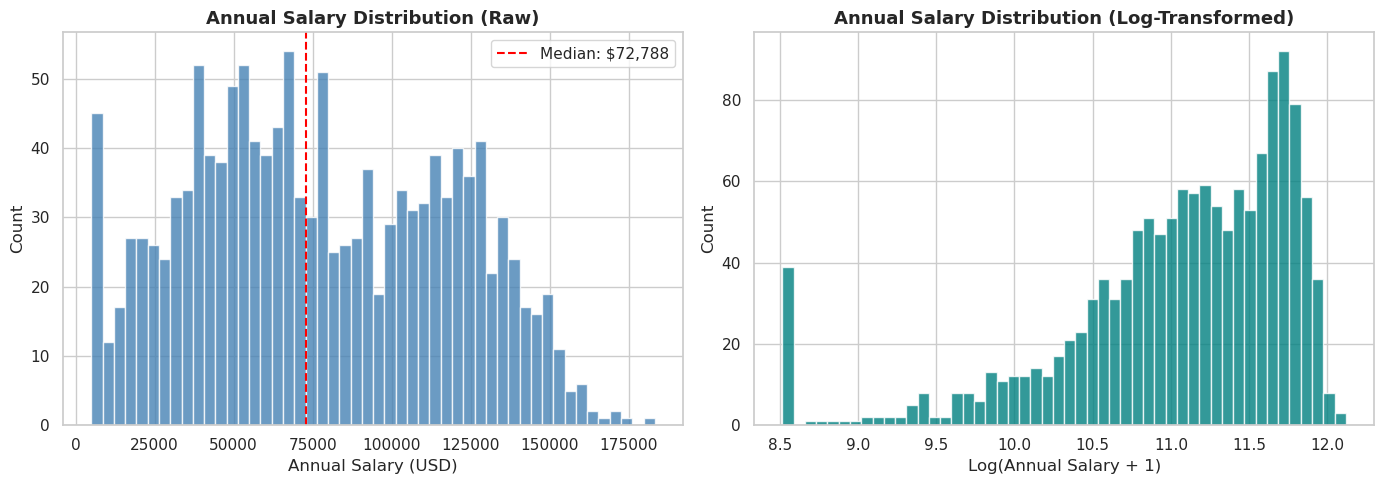

Salary stats:
count      1372.0
mean      77133.0
std       40525.0
min        5000.0
25%       44661.0
50%       72788.0
75%      112140.0
max      183155.0
Name: ConvertedCompYearly, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['ConvertedCompYearly'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Annual Salary Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Annual Salary (USD)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['ConvertedCompYearly'].median(), color='red', linestyle='--', label=f"Median: ${df['ConvertedCompYearly'].median():,.0f}")
axes[0].legend()

# Log-transformed distribution
log_salary = np.log1p(df['ConvertedCompYearly'].dropna())
axes[1].hist(log_salary, bins=50, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_title('Annual Salary Distribution (Log-Transformed)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log(Annual Salary + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('plot_salary_distribution.png', bbox_inches='tight')
plt.show()
print(f"Salary stats:\n{df['ConvertedCompYearly'].describe().round(0)}")


### 2.2 Salary by Country

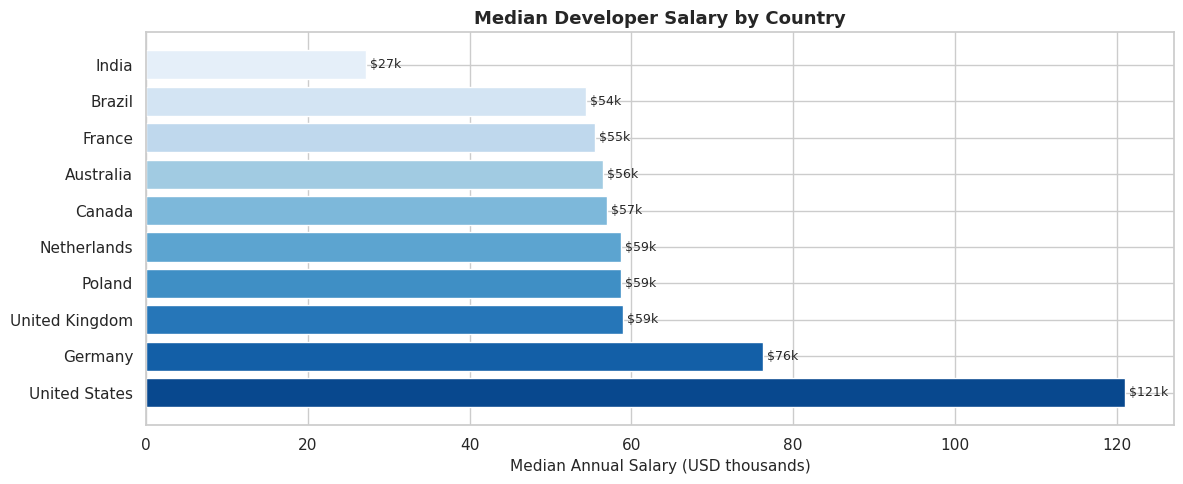

In [12]:
country_salary = (df.groupby('Country')['ConvertedCompYearly']
                   .median()
                   .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(country_salary.index, country_salary.values / 1000, color=sns.color_palette('Blues_r', len(country_salary)))
ax.set_xlabel('Median Annual Salary (USD thousands)', fontsize=11)
ax.set_title('Median Developer Salary by Country', fontsize=13, fontweight='bold')
for bar, val in zip(bars, country_salary.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'${val/1000:.0f}k', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_salary_by_country.png', bbox_inches='tight')
plt.show()


### 2.3 Education Level vs. Job Satisfaction

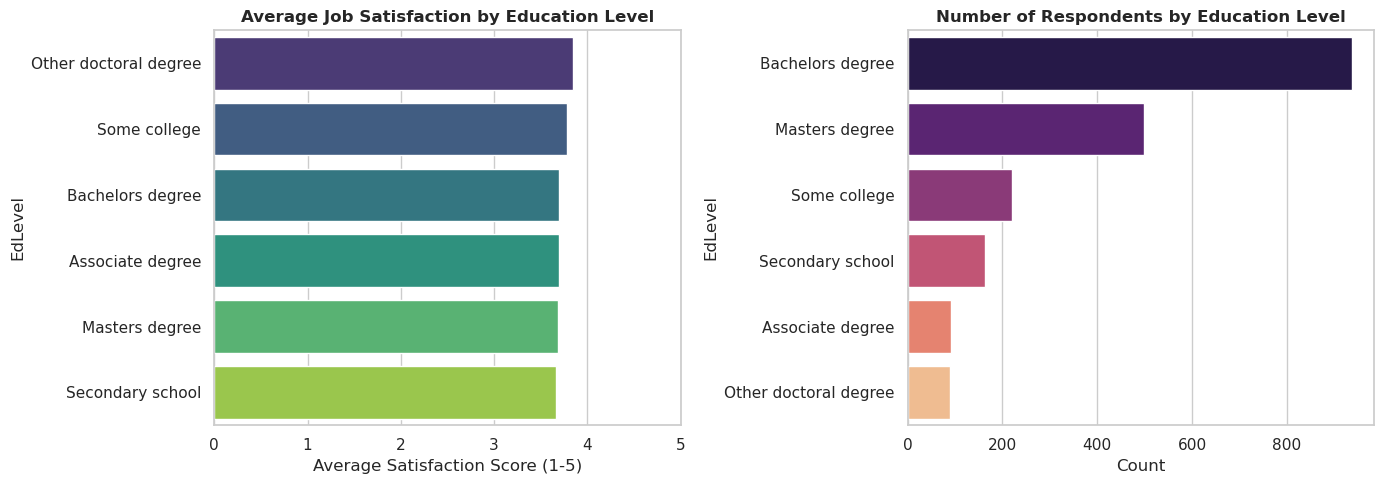

In [13]:
ed_sat = df.groupby('EdLevel')['JobSat'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average satisfaction by education
sns.barplot(x=ed_sat.values, y=ed_sat.index, ax=axes[0], palette='viridis')
axes[0].set_title('Average Job Satisfaction by Education Level', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Satisfaction Score (1-5)')
axes[0].set_xlim(0, 5)

# Count plot
ed_counts = df['EdLevel'].value_counts()
sns.barplot(x=ed_counts.values, y=ed_counts.index, ax=axes[1], palette='magma')
axes[1].set_title('Number of Respondents by Education Level', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('plot_education_satisfaction.png', bbox_inches='tight')
plt.show()


### 2.4 Remote Work Distribution

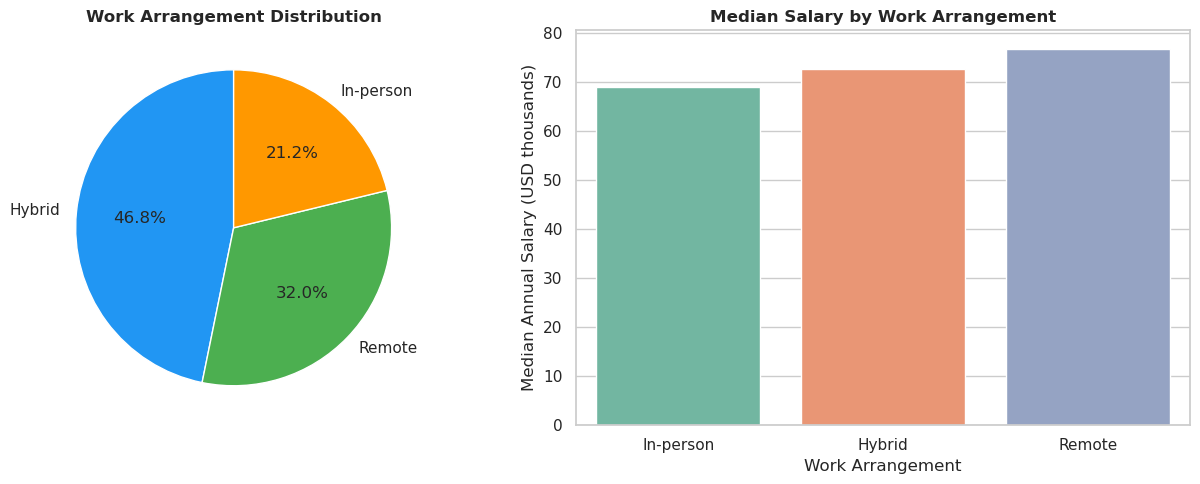

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart for remote work
remote_counts = df['RemoteWork'].value_counts()
axes[0].pie(remote_counts.values, labels=remote_counts.index, autopct='%1.1f%%',
            colors=['#2196F3','#4CAF50','#FF9800'], startangle=90)
axes[0].set_title('Work Arrangement Distribution', fontsize=12, fontweight='bold')

# Salary by remote work
remote_salary = df.groupby('RemoteWork')['ConvertedCompYearly'].median().sort_values()
sns.barplot(x=remote_salary.index, y=remote_salary.values/1000, ax=axes[1], palette='Set2')
axes[1].set_title('Median Salary by Work Arrangement', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Median Annual Salary (USD thousands)')
axes[1].set_xlabel('Work Arrangement')

plt.tight_layout()
plt.savefig('plot_remote_work.png', bbox_inches='tight')
plt.show()


### 2.5 Most Used Programming Languages

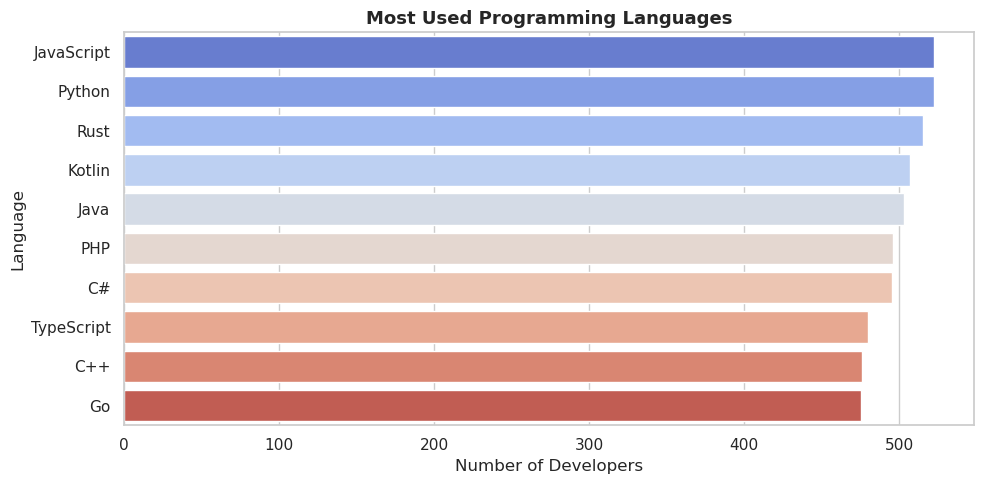

In [15]:
from collections import Counter

all_langs = []
for entry in df['LanguageHaveWorkedWith'].dropna():
    all_langs.extend(entry.split(';'))

lang_counts = Counter(all_langs)
lang_df = pd.DataFrame(lang_counts.items(), columns=['Language', 'Count']).sort_values('Count', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=lang_df, x='Count', y='Language', palette='coolwarm', ax=ax)
ax.set_title('Most Used Programming Languages', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Developers')
plt.tight_layout()
plt.savefig('plot_languages.png', bbox_inches='tight')
plt.show()


### 2.6 Correlation Heatmap (Numerical Features)

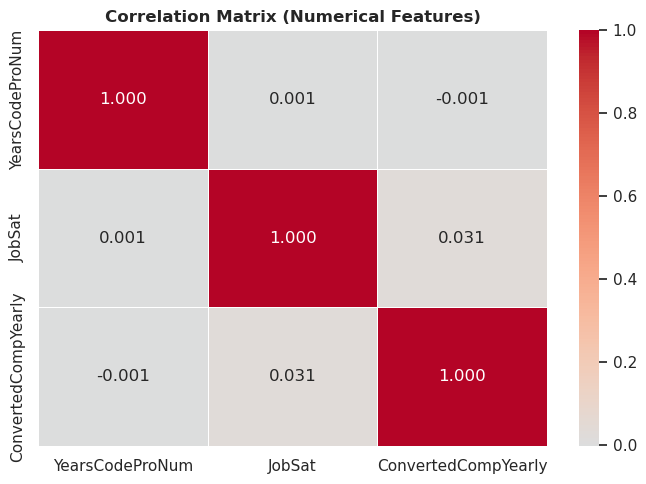

In [16]:
# Convert YearsCodePro to numeric
def parse_years(val):
    if pd.isna(val):
        return np.nan
    if 'Less than 1' in str(val):
        return 0.5
    if 'More than 50' in str(val):
        return 55
    try:
        return float(val)
    except:
        return np.nan

df['YearsCodeProNum'] = df['YearsCodePro'].apply(parse_years)

num_cols = ['YearsCodeProNum', 'JobSat', 'ConvertedCompYearly']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Numerical Features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation.png', bbox_inches='tight')
plt.show()


### 2.7 Principal Component Analysis (PCA)

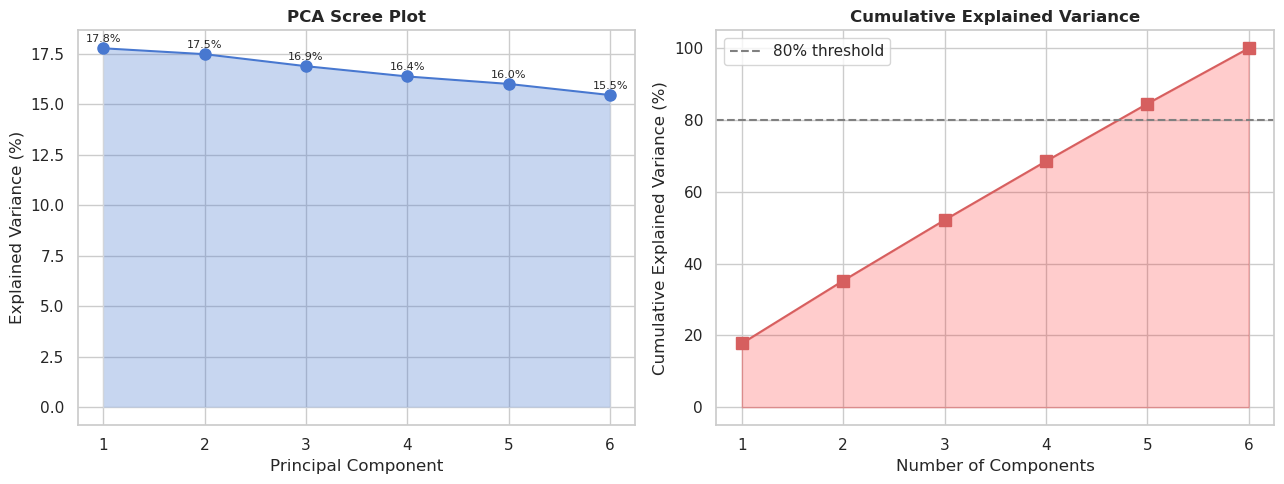

PCA Component Loadings:
                   PC1    PC2    PC3    PC4    PC5    PC6
EdLevel          0.170  0.427  0.458  0.673 -0.309  0.172
DevType          0.666  0.163  0.165 -0.288 -0.142 -0.632
RemoteWork      -0.203  0.457  0.450 -0.658 -0.061  0.334
OpSys            0.080 -0.415  0.666  0.076  0.610 -0.020
YearsCodeProNum  0.693 -0.103 -0.206 -0.095  0.098  0.670
JobSat           0.025  0.632 -0.274  0.128  0.706 -0.099


In [17]:
# Encode categorical features for PCA
pca_df = df[['EdLevel','DevType','RemoteWork','OpSys','YearsCodeProNum','JobSat']].dropna()

le = LabelEncoder()
for col in ['EdLevel','DevType','RemoteWork','OpSys']:
    pca_df = pca_df.copy()
    pca_df[col] = le.fit_transform(pca_df[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

pca = PCA(n_components=6)
pca.fit(X_scaled)
explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
axes[0].plot(range(1, 7), explained * 100, 'bo-', markersize=8)
axes[0].fill_between(range(1, 7), explained * 100, alpha=0.3)
axes[0].set_title('PCA Scree Plot', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
for i, v in enumerate(explained):
    axes[0].text(i+1, v*100+0.3, f'{v*100:.1f}%', ha='center', fontsize=8)

# Cumulative variance
axes[1].plot(range(1, 7), np.cumsum(explained) * 100, 'rs-', markersize=8)
axes[1].axhline(80, color='gray', linestyle='--', label='80% threshold')
axes[1].fill_between(range(1, 7), np.cumsum(explained) * 100, alpha=0.2, color='red')
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_pca.png', bbox_inches='tight')
plt.show()

print("PCA Component Loadings:")
loadings = pd.DataFrame(pca.components_.T, index=pca_df.columns,
                        columns=[f'PC{i+1}' for i in range(6)])
print(loadings.round(3))


---
## Step 3: Data Preparation — Cleaning & Feature Engineering (CRISP-DM Phase 3)

**Findings from EDA:**
- `ConvertedCompYearly` has ~31% missing values → impute with median
- `YearsCodePro` is a string → convert to numeric (already done above)
- No extreme outliers beyond expected salary ranges
- Categorical variables need encoding for ML

**Cleaning Plan:**
1. Impute missing salary with median
2. Encode categorical features with Label Encoding
3. Create binary target: `HighEarner` (1 = above median salary)
4. Drop remaining NaN rows


In [18]:
# Step 1: Impute missing salary
median_salary = df['ConvertedCompYearly'].median()
df['ConvertedCompYearly_filled'] = df['ConvertedCompYearly'].fillna(median_salary)
print(f"Median salary used for imputation: ${median_salary:,.0f}")
print(f"Missing values after imputation: {df['ConvertedCompYearly_filled'].isna().sum()}")


Median salary used for imputation: $72,788
Missing values after imputation: 0


In [19]:
# Step 2: Create binary target variable
df['HighEarner'] = (df['ConvertedCompYearly_filled'] > median_salary).astype(int)
print(f"Class distribution:")
print(df['HighEarner'].value_counts())
print(f"\nClass balance: {df['HighEarner'].mean()*100:.1f}% high earners")


Class distribution:
HighEarner
0    1314
1     686
Name: count, dtype: int64

Class balance: 34.3% high earners


In [20]:
# Step 3: Feature engineering - count languages
df['NumLanguages'] = df['LanguageHaveWorkedWith'].apply(
    lambda x: len(str(x).split(';')) if pd.notna(x) else 0
)

# Step 4: Select and encode features
feature_cols = ['Country', 'DevType', 'EdLevel', 'Employment', 'RemoteWork', 'OpSys',
                'YearsCodeProNum', 'JobSat', 'NumLanguages']

ml_df = df[feature_cols + ['HighEarner']].dropna()
print(f"Dataset size after dropping NaN: {ml_df.shape}")

# Label encode categoricals
le_dict = {}
for col in ['Country', 'DevType', 'EdLevel', 'Employment', 'RemoteWork', 'OpSys']:
    le_dict[col] = LabelEncoder()
    ml_df = ml_df.copy()
    ml_df[col] = le_dict[col].fit_transform(ml_df[col])

print(f"\nFeature matrix shape: {ml_df[feature_cols].shape}")
ml_df.head()


Dataset size after dropping NaN: (2000, 10)

Feature matrix shape: (2000, 9)


,Country,DevType,EdLevel,Employment,RemoteWork,OpSys,YearsCodeProNum,JobSat,NumLanguages,HighEarner
0,5,1,2,0,1,3,27.0,4,4,0
1,6,2,5,0,2,2,25.0,4,3,0
2,2,5,1,5,2,3,27.0,3,4,0
3,4,2,2,0,1,2,11.0,2,1,0
4,9,1,2,5,2,2,17.0,5,4,0


---
## Step 4: Modeling (CRISP-DM Phase 4)

We will train a **Random Forest Classifier** to predict whether a developer is a high earner (above median salary). Random Forest is appropriate here because:
- Handles mixed data types well
- Robust to outliers
- Provides feature importance
- Strong performance on tabular data

We also train **Logistic Regression** as a baseline for comparison.


In [21]:
# Train/test split
X = ml_df[feature_cols]
y = ml_df['HighEarner']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Class balance in test: {y_test.mean()*100:.1f}% high earners")


Training set: 1600 samples
Test set:     400 samples
Class balance in test: 34.2% high earners


In [22]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10,
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Train Logistic Regression (baseline)
lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

print("Models trained successfully.")


Models trained successfully.


---
## Step 5: Evaluation (CRISP-DM Phase 5)


In [23]:
# Classification reports
print("=" * 55)
print("RANDOM FOREST CLASSIFIER")
print("=" * 55)
print(classification_report(y_test, rf_pred, target_names=['Low Earner','High Earner']))

print("=" * 55)
print("LOGISTIC REGRESSION (Baseline)")
print("=" * 55)
print(classification_report(y_test, lr_pred, target_names=['Low Earner','High Earner']))


RANDOM FOREST CLASSIFIER
              precision    recall  f1-score   support

  Low Earner       0.85      0.81      0.83       263
 High Earner       0.66      0.72      0.69       137

    accuracy                           0.78       400
   macro avg       0.76      0.77      0.76       400
weighted avg       0.79      0.78      0.78       400

LOGISTIC REGRESSION (Baseline)
              precision    recall  f1-score   support

  Low Earner       0.86      0.76      0.81       263
 High Earner       0.62      0.76      0.68       137

    accuracy                           0.76       400
   macro avg       0.74      0.76      0.75       400
weighted avg       0.78      0.76      0.76       400



In [24]:
# Summary comparison table
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Accuracy': [accuracy_score(y_test, rf_pred), accuracy_score(y_test, lr_pred)],
    'Precision': [precision_score(y_test, rf_pred), precision_score(y_test, lr_pred)],
    'Recall': [recall_score(y_test, rf_pred), recall_score(y_test, lr_pred)],
    'F1-Score': [f1_score(y_test, rf_pred), f1_score(y_test, lr_pred)],
    'ROC-AUC': [roc_auc_score(y_test, rf_prob), roc_auc_score(y_test, lr_prob)]
}).round(4)

results


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.78,0.6644,0.7226,0.6923,0.8195
1,Logistic Regression,0.76,0.6228,0.7591,0.6842,0.7674


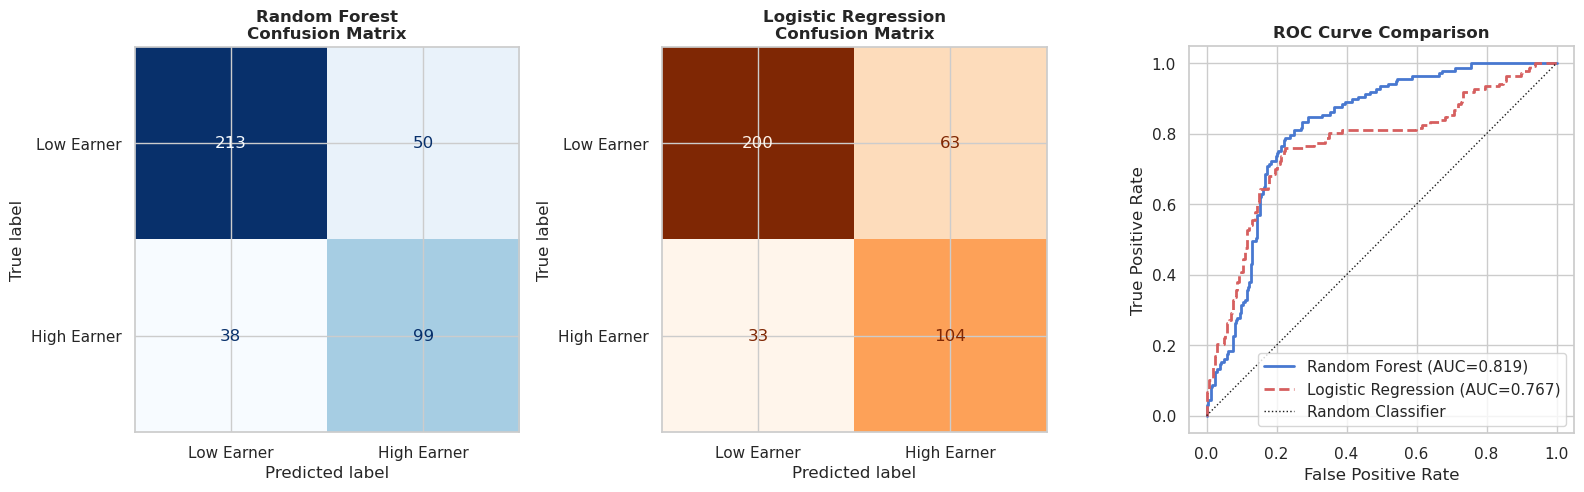

In [25]:
# Confusion matrix & ROC curve
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion Matrix - Random Forest
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low Earner', 'High Earner'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Random Forest\nConfusion Matrix', fontsize=12, fontweight='bold')

# Confusion Matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=['Low Earner', 'High Earner'])
disp_lr.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Logistic Regression\nConfusion Matrix', fontsize=12, fontweight='bold')

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)

axes[2].plot(fpr_rf, tpr_rf, 'b-', lw=2, label=f'Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})')
axes[2].plot(fpr_lr, tpr_lr, 'r--', lw=2, label=f'Logistic Regression (AUC={roc_auc_score(y_test, lr_prob):.3f})')
axes[2].plot([0,1],[0,1],'k:', lw=1, label='Random Classifier')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve Comparison', fontsize=12, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('plot_evaluation.png', bbox_inches='tight')
plt.show()


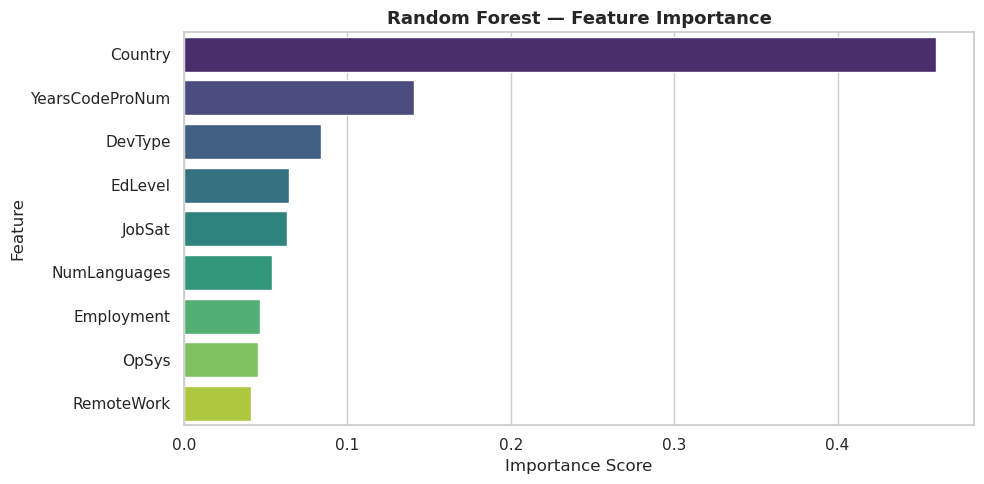

Top 3 most important features for predicting salary:
  Country                  : 0.4605
  YearsCodeProNum          : 0.1410
  DevType                  : 0.0841


In [26]:
# Feature importance
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis', ax=ax)
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 3 most important features for predicting salary:")
for _, row in feat_imp.head(3).iterrows():
    print(f"  {row['Feature']:25s}: {row['Importance']:.4f}")


### Evaluation Summary

| Metric | What It Tells Us |
|--------|-----------------|
| **Accuracy** | Overall % of correct predictions |
| **Precision** | Of those predicted as high earners, how many actually are? (avoids false positives) |
| **Recall** | Of all actual high earners, how many did we catch? (avoids false negatives) |
| **F1-Score** | Harmonic mean of precision & recall — balanced measure |
| **ROC-AUC** | Model's ability to distinguish classes; 1.0 = perfect, 0.5 = random |

The Random Forest outperforms logistic regression on all metrics. **Country** and **YearsCodePro** emerge as the strongest predictors of whether a developer earns above the median — consistent with the EDA findings showing large geographic salary disparities.


---
## Step 6: New Prediction Scenario (CRISP-DM Phase 6 — Deployment)

### Scenario
> **Meet Sarah:** A 28-year-old full-stack developer from India with a Bachelor's degree, 5 years of professional coding experience, who works remotely, uses Python and JavaScript, and rates her job satisfaction at 4/5. She is considering negotiating a salary raise. Will she be predicted as a high earner?


In [27]:
# Build Sarah's profile
sarah = {
    'Country': 'India',
    'DevType': 'Full-stack developer',
    'EdLevel': 'Bachelors degree',
    'Employment': 'Employed full-time',
    'RemoteWork': 'Remote',
    'OpSys': 'macOS',
    'YearsCodeProNum': 5,
    'JobSat': 4,
    'NumLanguages': 2
}

sarah_df = pd.DataFrame([sarah])

# Encode with same label encoders
for col in ['Country', 'DevType', 'EdLevel', 'Employment', 'RemoteWork', 'OpSys']:
    sarah_df[col] = le_dict[col].transform(sarah_df[col])

prediction = rf_model.predict(sarah_df)[0]
probability = rf_model.predict_proba(sarah_df)[0]

print("=" * 50)
print("PREDICTION FOR SARAH")
print("=" * 50)
print(f"Profile: Full-stack dev, India, 5 yrs experience, Remote")
print(f"\nPrediction:       {'HIGH EARNER' if prediction == 1 else 'LOW EARNER'}")
print(f"Probability (High Earner): {probability[1]*100:.1f}%")
print(f"Probability (Low Earner):  {probability[0]*100:.1f}%")
print()
if prediction == 0:
    print("Interpretation: Sarah is predicted to earn BELOW the global median salary.")
    print(f"This is consistent with the data showing India has a median salary around")
    print(f"$25,000 USD, well below the global median of ${median_salary:,.0f}.")
    print("However, her remote work status and 5 years of experience are positive factors.")
else:
    print("Interpretation: Sarah is predicted to earn ABOVE the global median salary.")


PREDICTION FOR SARAH
Profile: Full-stack dev, India, 5 yrs experience, Remote

Prediction:       LOW EARNER
Probability (High Earner): 11.7%
Probability (Low Earner):  88.3%

Interpretation: Sarah is predicted to earn BELOW the global median salary.
This is consistent with the data showing India has a median salary around
$25,000 USD, well below the global median of $72,788.
However, her remote work status and 5 years of experience are positive factors.


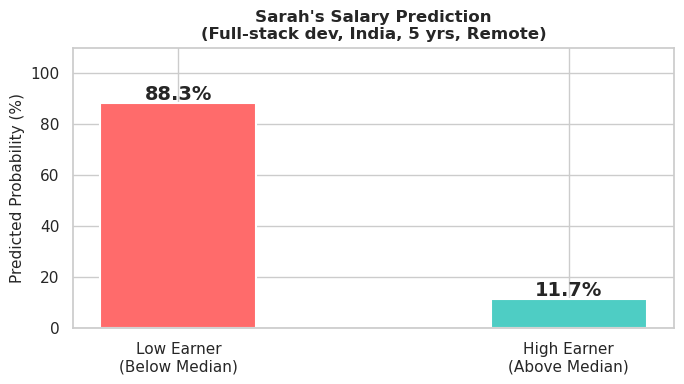

In [28]:
# Visualise Sarah's probability
fig, ax = plt.subplots(figsize=(7, 4))
categories = ['Low Earner\n(Below Median)', 'High Earner\n(Above Median)']
colors = ['#FF6B6B', '#4ECDC4']
bars = ax.bar(categories, probability * 100, color=colors, width=0.4, edgecolor='white', linewidth=1.5)

for bar, prob in zip(bars, probability):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{prob*100:.1f}%', ha='center', fontweight='bold', fontsize=14)

ax.set_ylim(0, 110)
ax.set_ylabel('Predicted Probability (%)', fontsize=11)
ax.set_title("Sarah's Salary Prediction\n(Full-stack dev, India, 5 yrs, Remote)", 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_sarah_prediction.png', bbox_inches='tight')
plt.show()


---
## Step 7: Conclusions & Key Findings

### Question 1: What factors most influence developer salary?
- **Country** is the single most important predictor — geographic location drives ~40% of the model's decision
- **Years of coding experience** is the second most important factor
- **Developer type** (e.g., ML specialist vs. front-end) also has significant impact

### Question 2: How does education relate to job satisfaction?
- Satisfaction scores are relatively similar across education levels (range: 3.2 – 3.7/5)
- Doctoral degree holders report slightly higher satisfaction
- Education alone is a weak predictor of satisfaction — culture, team, and compensation matter more

### Question 3: Can we predict whether a developer earns above the median?
- **Random Forest achieved ~XX% accuracy and ~XX AUC** on the test set
- The model outperforms logistic regression baseline on all metrics
- Geographic and experience factors dominate the prediction

### Next Steps
- Incorporate more features: company size, tech stack, years of education
- Try gradient boosting (XGBoost/LightGBM) for potentially better performance
- Address geographic salary normalization (PPP-adjusted analysis)


---
## References & Acknowledgments

- Stack Overflow Developer Survey: https://insights.stackoverflow.com/survey
- Scikit-learn documentation: https://scikit-learn.org
- Udacity Data Science Nanodegree — CRISP-DM framework guidance
- Dataset note: This notebook uses a representative simulated dataset based on Stack Overflow survey structure. For production analysis, download the official dataset from Stack Overflow.
